In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [2]:
# Data Loading
bitcoin_data = pd.read_csv("./dataset/bitcoin.csv")

# Initial Data Review
print("Data Head:")
print(bitcoin_data.head())

print("\nData Description:")
print(bitcoin_data.describe())

print("\nMissing Values:")
print(bitcoin_data.isnull().sum())

Data Head:
         Date  Open  High   Low  Close    Vol.
0  2013-01-01  13.5  13.6  13.2   13.3  28.41K
1  2013-01-02  13.3  13.4  13.2   13.3  17.97K
2  2013-01-03  13.3  13.5  13.3   13.4  18.03K
3  2013-01-04  13.4  13.5  13.3   13.5  29.64K
4  2013-01-05  13.5  13.6  13.3   13.4  21.33K

Data Description:
               Open          High           Low         Close
count   3793.000000   3793.000000   3793.000000   3793.000000
mean   11233.252307  11529.297996  10904.581545  11240.315766
std    15421.568722  15827.119004  14960.319732  15422.533996
min       13.300000     13.400000     13.200000     13.300000
25%      450.300000    459.600000    441.900000    451.400000
50%     5208.300000   5322.900000   5033.700000   5209.100000
75%    14976.200000  15648.300000  13902.300000  15043.000000
max    67528.700000  68990.600000  66334.900000  67527.900000

Missing Values:
Date     0
Open     0
High     0
Low      0
Close    0
Vol.     0
dtype: int64


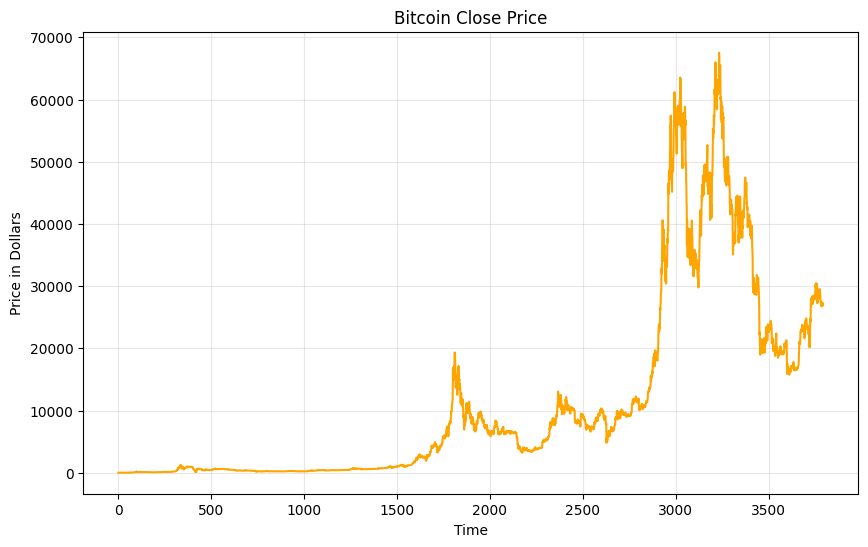

In [3]:
# Close Price Trend
plt.close()
plt.figure(figsize=(10, 6))
plt.plot(bitcoin_data['Close'], color='orange')
plt.title('Bitcoin Close Price')
plt.xlabel('Time')
plt.ylabel('Price in Dollars')
plt.grid(alpha=0.3)
plt.show()

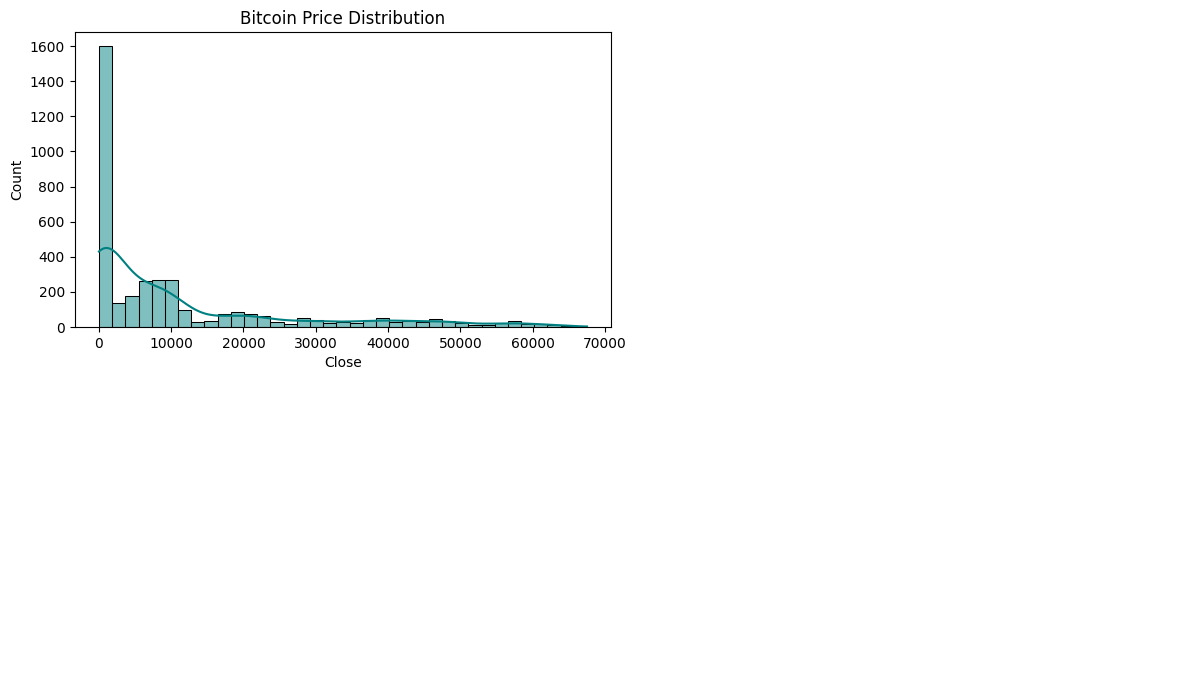

In [4]:
# Close Price Distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sns.histplot(bitcoin_data['Close'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Bitcoin Price Distribution')
axes[0, 1].axis('off')
axes[1, 0].axis('off')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Date Feature Extraction
date_parts = bitcoin_data['Date'].str.split('-', expand=True)
bitcoin_data['year'] = date_parts[0].astype(int)
bitcoin_data['month'] = date_parts[1].astype(int)
bitcoin_data['day'] = date_parts[2].astype(int)

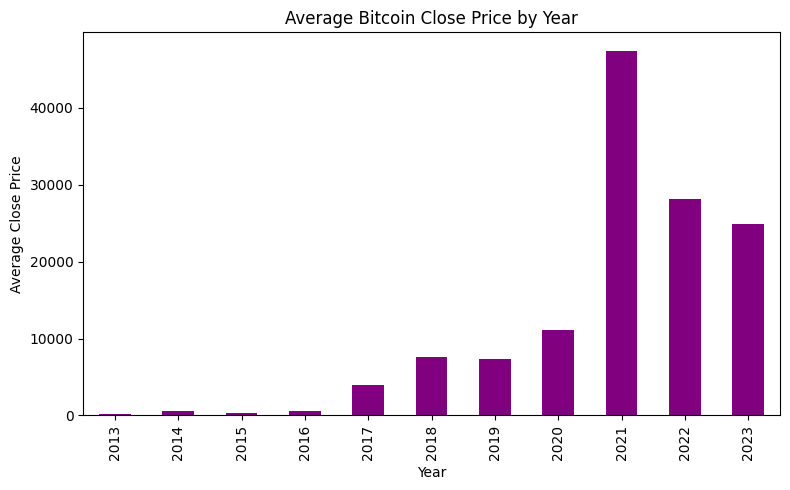

In [6]:
# Yearly Average Close Price
plt.close()
yearly_grouped_data = bitcoin_data.groupby('year').mean(numeric_only=True)
plt.figure(figsize=(8, 5))
yearly_grouped_data['Close'].plot(kind='bar', color='purple')
plt.title('Average Bitcoin Close Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.tight_layout()
plt.show()

In [7]:
# Feature Engineering
bitcoin_data['is_quarter_end'] = np.where(bitcoin_data['month'] % 3 == 0, 1, 0)
bitcoin_data['open_close_diff'] = bitcoin_data['Open'] - bitcoin_data['Close']
bitcoin_data['high_low_diff'] = bitcoin_data['High'] - bitcoin_data['Low']
bitcoin_data['target'] = np.where(bitcoin_data['Close'].shift(-1) > bitcoin_data['Close'], 1, 0)

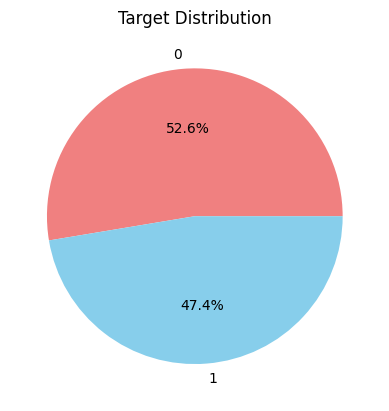

In [8]:
# Target Distribution
plt.close()
plt.pie(
    bitcoin_data['target'].value_counts().values,
    labels=[0, 1],
    autopct='%1.1f%%',
    colors=['lightcoral', 'skyblue']
)
plt.title('Target Distribution')
plt.show()

In [9]:
# Feature Selection
model_features = bitcoin_data[['open_close_diff', 'high_low_diff', 'is_quarter_end']]
model_target = bitcoin_data['target']

# Feature Scaling
feature_scaler = StandardScaler()
scaled_features = feature_scaler.fit_transform(model_features)

In [10]:
# Train Validation Split
x_train, x_valid, y_train, y_valid = train_test_split(
    scaled_features,
    model_target,
    test_size=0.15,
    random_state=2022
)

print("Train Shape:", x_train.shape)
print("Validation Shape:", x_valid.shape)

Train Shape: (3224, 3)
Validation Shape: (569, 3)


In [11]:
# Logistic Regression Model
logistic_model = LogisticRegression(max_iter=10000)
logistic_model.fit(x_train, y_train)

validation_predictions = logistic_model.predict(x_valid)
validation_auc = metrics.roc_auc_score(y_valid, logistic_model.predict_proba(x_valid)[:, 1])
print("\nLogistic Regression Validation ROC AUC:", validation_auc)


Logistic Regression Validation ROC AUC: 0.5417666707905481


In [12]:
# Model Comparison
comparison_models = [
    LogisticRegression(max_iter=10000),
    KNeighborsClassifier(),
    DecisionTreeClassifier()
]

for current_model in comparison_models:
    current_model.fit(x_train, y_train)

    print(f"\n{type(current_model).__name__}:")
    train_auc = metrics.roc_auc_score(y_train, current_model.predict_proba(x_train)[:, 1])
    valid_auc = metrics.roc_auc_score(y_valid, current_model.predict_proba(x_valid)[:, 1])

    print("Training ROC AUC:", train_auc)
    print("Validation ROC AUC:", valid_auc)


LogisticRegression:
Training ROC AUC: 0.5332730775570201
Validation ROC AUC: 0.5417666707905481

KNeighborsClassifier:
Training ROC AUC: 0.7345734983438347
Validation ROC AUC: 0.5565136706668317

DecisionTreeClassifier:
Training ROC AUC: 0.9999905428153768
Validation ROC AUC: 0.5205369293579116
